In [4]:
"""
=================================================================
STEP 1: Detection Rate by Metric (Filtered)
PURPOSE: Table 5 - Detection rates for P, Hf, Hb, delta_H, Reward
=================================================================
"""
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds (updated list)
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]

# Exclude baseline rows
df_pert = df[df['perturbation'] != 'no_noise (baseline)'].copy()

# Add algorithm column
df_pert['algorithm'] = df_pert['UID'].apply(lambda x: 'SAC' if 'sac' in x else 'PPO')

# Detection rate per seed
metrics = ['P', 'Hf', 'Hb', 'delta_H', 'mean_reward']

print("=" * 70)
print("TABLE 5: Detection Rate by Metric (3σ threshold)")
print("=" * 70)

for algo in ['SAC', 'PPO']:
    algo_df = df_pert[df_pert['algorithm'] == algo]
    seeds = algo_df['UID'].unique()
    n_seeds = len(seeds)

    print(f"\n{algo} (n={n_seeds} seeds):")
    print("-" * 50)

    for m in metrics:
        col = f't_{m}'
        rates = []
        for seed in seeds:
            seed_df = algo_df[algo_df['UID'] == seed]
            detected = seed_df[col].notna().sum()
            total = len(seed_df)
            rates.append(detected / total * 100)

        mean_rate = np.mean(rates)
        std_rate = np.std(rates)
        m_label = 'Reward' if m == 'mean_reward' else m
        print(f"  {m_label:<10}: {mean_rate:5.1f} ± {std_rate:4.1f}%")

# Combined
print("\n" + "=" * 70)
print("COMBINED (n=21 seeds):")
print("-" * 50)

seeds = df_pert['UID'].unique()
for m in metrics:
    col = f't_{m}'
    rates = []
    for seed in seeds:
        seed_df = df_pert[df_pert['UID'] == seed]
        detected = seed_df[col].notna().sum()
        total = len(seed_df)
        rates.append(detected / total * 100)

    mean_rate = np.mean(rates)
    std_rate = np.std(rates)
    m_label = 'Reward' if m == 'mean_reward' else m
    print(f"  {m_label:<10}: {mean_rate:5.1f} ± {std_rate:4.1f}%")

TABLE 5: Detection Rate by Metric (3σ threshold)

SAC (n=11 seeds):
--------------------------------------------------
  P         :  70.5 ± 24.6%
  Hf        :  68.2 ± 25.8%
  Hb        :  65.9 ± 22.0%
  delta_H   :  70.5 ± 19.4%
  Reward    :  35.2 ± 25.5%

PPO (n=10 seeds):
--------------------------------------------------
  P         :  76.2 ± 14.2%
  Hf        :  73.8 ± 13.1%
  Hb        :  73.8 ± 20.5%
  delta_H   :  67.5 ± 21.1%
  Reward    :  53.8 ± 23.1%

COMBINED (n=21 seeds):
--------------------------------------------------
  P         :  73.2 ± 20.5%
  Hf        :  70.8 ± 20.9%
  Hb        :  69.6 ± 21.7%
  delta_H   :  69.0 ± 20.3%
  Reward    :  44.0 ± 26.1%


In [5]:
"""
=================================================================
STEP 2b: Detection Rate WITH IDT Union
STEP 3: Detection Latency WITH IDT First
=================================================================
"""
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]

# Exclude baseline rows
df_pert = df[df['perturbation'] != 'no_noise (baseline)'].copy()

# Add algorithm column
df_pert['algorithm'] = df_pert['UID'].apply(lambda x: 'SAC' if 'sac' in x else 'PPO')

# Add IDT columns
df_pert['t_IDT'] = df_pert[['t_P', 't_Hf', 't_Hb', 't_delta_H']].min(axis=1)  # First to detect
df_pert['IDT_detected'] = df_pert[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1)  # Any detected

metrics = ['P', 'Hf', 'Hb', 'delta_H', 'mean_reward']

# ============ TABLE 5b: Detection Rate with IDT ============
print("=" * 70)
print("TABLE 5b: Detection Rate by Metric (3σ threshold) - WITH IDT")
print("=" * 70)

for algo in ['SAC', 'PPO', 'COMBINED']:
    if algo == 'COMBINED':
        algo_df = df_pert
        n_seeds = len(df_pert['UID'].unique())
    else:
        algo_df = df_pert[df_pert['algorithm'] == algo]
        n_seeds = len(algo_df['UID'].unique())

    seeds = algo_df['UID'].unique()

    print(f"\n{algo} (n={n_seeds} seeds):")
    print("-" * 50)

    # Individual metrics
    for m in metrics:
        col = f't_{m}'
        rates = []
        for seed in seeds:
            seed_df = algo_df[algo_df['UID'] == seed]
            detected = seed_df[col].notna().sum()
            total = len(seed_df)
            rates.append(detected / total * 100)

        mean_rate = np.mean(rates)
        std_rate = np.std(rates)
        m_label = 'Reward' if m == 'mean_reward' else m
        print(f"  {m_label:<10}: {mean_rate:5.1f} ± {std_rate:4.1f}%")

    # IDT (any)
    rates = []
    for seed in seeds:
        seed_df = algo_df[algo_df['UID'] == seed]
        detected = seed_df['IDT_detected'].sum()
        total = len(seed_df)
        rates.append(detected / total * 100)

    mean_rate = np.mean(rates)
    std_rate = np.std(rates)
    print(f"  {'IDT (any)':<10}: {mean_rate:5.1f} ± {std_rate:4.1f}%  <-- UNION")

# ============ TABLE 6: Detection Latency ============
print("\n" + "=" * 70)
print("TABLE 6: Median Detection Latency (windows after perturbation onset)")
print("=" * 70)

metrics_with_idt = ['P', 'Hf', 'Hb', 'delta_H', 'IDT', 'mean_reward']

for algo in ['SAC', 'PPO', 'COMBINED']:
    if algo == 'COMBINED':
        algo_df = df_pert
    else:
        algo_df = df_pert[df_pert['algorithm'] == algo]

    print(f"\n{algo}:")
    print("-" * 50)

    for m in metrics_with_idt:
        col = f't_{m}' if m != 'IDT' else 't_IDT'
        latencies = algo_df[col].dropna().values
        if len(latencies) > 0:
            median_lat = np.median(latencies)
            m_label = 'Reward' if m == 'mean_reward' else m
            print(f"  {m_label:<10}: {median_lat:6.0f} (n={len(latencies)})")
        else:
            print(f"  {m:<10}: NaN")

TABLE 5b: Detection Rate by Metric (3σ threshold) - WITH IDT

SAC (n=11 seeds):
--------------------------------------------------
  P         :  70.5 ± 24.6%
  Hf        :  68.2 ± 25.8%
  Hb        :  65.9 ± 22.0%
  delta_H   :  70.5 ± 19.4%
  Reward    :  35.2 ± 25.5%
  IDT (any) :  85.2 ± 19.1%  <-- UNION

PPO (n=10 seeds):
--------------------------------------------------
  P         :  76.2 ± 14.2%
  Hf        :  73.8 ± 13.1%
  Hb        :  73.8 ± 20.5%
  delta_H   :  67.5 ± 21.1%
  Reward    :  53.8 ± 23.1%
  IDT (any) :  93.8 ±  6.2%  <-- UNION

COMBINED (n=21 seeds):
--------------------------------------------------
  P         :  73.2 ± 20.5%
  Hf        :  70.8 ± 20.9%
  Hb        :  69.6 ± 21.7%
  delta_H   :  69.0 ± 20.3%
  Reward    :  44.0 ± 26.1%
  IDT (any) :  89.3 ± 15.1%  <-- UNION

TABLE 6: Median Detection Latency (windows after perturbation onset)

SAC:
--------------------------------------------------
  P         :      6 (n=62)
  Hf        :     10 (n=60)
  Hb

In [6]:
"""
=================================================================
STEP 4: Effect Size (Cohen's d) - Table 7
PURPOSE: Compare effect magnitude across metrics
=================================================================
"""
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]

# Exclude baseline rows
df_pert = df[df['perturbation'] != 'no_noise (baseline)'].copy()

# Add algorithm column
df_pert['algorithm'] = df_pert['UID'].apply(lambda x: 'SAC' if 'sac' in x else 'PPO')

metrics = ['P', 'Hf', 'Hb', 'delta_H', 'mean_reward']

print("=" * 70)
print("TABLE 7: Mean |Effect Size| (Cohen's d)")
print("=" * 70)

for algo in ['SAC', 'PPO', 'COMBINED']:
    if algo == 'COMBINED':
        algo_df = df_pert
        n_seeds = len(df_pert['UID'].unique())
    else:
        algo_df = df_pert[df_pert['algorithm'] == algo]
        n_seeds = len(algo_df['UID'].unique())

    print(f"\n{algo} (n={n_seeds} seeds):")
    print("-" * 50)

    for m in metrics:
        col = f'd_{m}'
        d_values = algo_df[col].abs().values
        mean_d = np.mean(d_values)
        std_d = np.std(d_values)
        m_label = 'Reward' if m == 'mean_reward' else m
        print(f"  {m_label:<10}: {mean_d:5.2f} ± {std_d:4.2f}")

# ============ Sensitivity Ratio ============
print("\n" + "=" * 70)
print("SENSITIVITY RATIO (|d_metric| / |d_Reward|)")
print("=" * 70)

for algo in ['SAC', 'PPO', 'COMBINED']:
    if algo == 'COMBINED':
        algo_df = df_pert
    else:
        algo_df = df_pert[df_pert['algorithm'] == algo]

    print(f"\n{algo}:")
    print("-" * 50)

    d_reward = algo_df['d_mean_reward'].abs().mean()

    for m in ['P', 'Hf', 'Hb', 'delta_H']:
        d_m = algo_df[f'd_{m}'].abs().mean()
        ratio = d_m / d_reward if d_reward > 0.001 else np.inf
        print(f"  |d_{m}| / |d_Reward| = {d_m:.2f} / {d_reward:.2f} = {ratio:.1f}x")

TABLE 7: Mean |Effect Size| (Cohen's d)

SAC (n=11 seeds):
--------------------------------------------------
  P         :  1.31 ± 1.33
  Hf        :  1.46 ± 1.49
  Hb        :  1.42 ± 1.57
  delta_H   :  1.42 ± 1.70
  Reward    :  0.66 ± 1.12

PPO (n=10 seeds):
--------------------------------------------------
  P         :  0.51 ± 0.58
  Hf        :  0.54 ± 0.98
  Hb        :  0.50 ± 0.89
  delta_H   :  0.39 ± 0.52
  Reward    :  0.53 ± 0.69

COMBINED (n=21 seeds):
--------------------------------------------------
  P         :  0.93 ± 1.12
  Hf        :  1.02 ± 1.35
  Hb        :  0.98 ± 1.37
  delta_H   :  0.93 ± 1.38
  Reward    :  0.60 ± 0.94

SENSITIVITY RATIO (|d_metric| / |d_Reward|)

SAC:
--------------------------------------------------
  |d_P| / |d_Reward| = 1.31 / 0.66 = 2.0x
  |d_Hf| / |d_Reward| = 1.46 / 0.66 = 2.2x
  |d_Hb| / |d_Reward| = 1.42 / 0.66 = 2.1x
  |d_delta_H| / |d_Reward| = 1.42 / 0.66 = 2.1x

PPO:
--------------------------------------------------
  |d_

In [7]:
"""
=================================================================
STEP 5: Dose-Response Analysis
PURPOSE: Does |d| scale with perturbation strength?
=================================================================
"""
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]

# Exclude baseline rows
df_pert = df[df['perturbation'] != 'no_noise (baseline)'].copy()

# Add algorithm column
df_pert['algorithm'] = df_pert['UID'].apply(lambda x: 'SAC' if 'sac' in x else 'PPO')

metrics = ['P', 'Hf', 'Hb', 'delta_H', 'mean_reward']

# Define dose groups
dose_groups = {
    'act_noise': ['act_noise_01%', 'act_noise_03%', 'act_noise_04%'],
    'obs_noise': ['obs_noise_01%', 'obs_noise_03%'],
    'force_torso': ['force_torso_5N', 'force_torso_10N']
}

print("=" * 70)
print("DOSE-RESPONSE ANALYSIS: Mean |d| by Perturbation Strength")
print("=" * 70)

for group_name, perturbations in dose_groups.items():
    print(f"\n{'='*70}")
    print(f"{group_name.upper()}")
    print("=" * 70)

    # Header
    header = f"{'Metric':<12}"
    for p in perturbations:
        short_name = p.replace('act_noise_', '').replace('obs_noise_', '').replace('force_torso_', '')
        header += f"{short_name:>12}"
    header += f"{'Trend':>12}"
    print(header)
    print("-" * len(header))

    for m in metrics:
        m_label = 'Reward' if m == 'mean_reward' else m
        row = f"{m_label:<12}"

        d_values = []
        for p in perturbations:
            p_df = df_pert[df_pert['perturbation'] == p]
            mean_d = p_df[f'd_{m}'].abs().mean()
            d_values.append(mean_d)
            row += f"{mean_d:>12.2f}"

        # Check trend (increasing?)
        if len(d_values) >= 2:
            if all(d_values[i] <= d_values[i+1] for i in range(len(d_values)-1)):
                trend = "↑ YES"
            elif all(d_values[i] >= d_values[i+1] for i in range(len(d_values)-1)):
                trend = "↓ REV"
            else:
                trend = "~ MIXED"
        else:
            trend = "N/A"

        row += f"{trend:>12}"
        print(row)

# ============ BY ALGORITHM ============
print("\n" + "=" * 70)
print("DOSE-RESPONSE BY ALGORITHM (P metric only)")
print("=" * 70)

for algo in ['SAC', 'PPO']:
    algo_df = df_pert[df_pert['algorithm'] == algo]

    print(f"\n{algo}:")
    print("-" * 50)

    for group_name, perturbations in dose_groups.items():
        row = f"  {group_name:<12}: "
        d_values = []
        for p in perturbations:
            p_df = algo_df[algo_df['perturbation'] == p]
            mean_d = p_df['d_P'].abs().mean()
            d_values.append(mean_d)
            short_name = p.replace('act_noise_', '').replace('obs_noise_', '').replace('force_torso_', '')
            row += f"{short_name}={mean_d:.2f}  "

        # Trend
        if all(d_values[i] <= d_values[i+1] for i in range(len(d_values)-1)):
            row += "↑"
        elif all(d_values[i] >= d_values[i+1] for i in range(len(d_values)-1)):
            row += "↓"
        else:
            row += "~"

        print(row)

DOSE-RESPONSE ANALYSIS: Mean |d| by Perturbation Strength

ACT_NOISE
Metric               01%         03%         04%       Trend
------------------------------------------------------------
P                   0.65        0.95        1.07       ↑ YES
Hf                  0.68        1.17        1.47       ↑ YES
Hb                  0.67        1.12        1.40       ↑ YES
delta_H             0.64        1.05        1.18       ↑ YES
Reward              0.16        0.34        0.49       ↑ YES

OBS_NOISE
Metric               01%         03%       Trend
------------------------------------------------
P                   0.91        1.76       ↑ YES
Hf                  1.04        2.14       ↑ YES
Hb                  1.01        2.08       ↑ YES
delta_H             1.06        1.61       ↑ YES
Reward              0.41        1.74       ↑ YES

FORCE_TORSO
Metric                5N         10N       Trend
------------------------------------------------
P                   0.28        0.50   

In [8]:
"""
=================================================================
STEP 6: Component Sensitivity by Perturbation Type
PURPOSE: Which IDT metric is best for which perturbation?
=================================================================
"""
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]

# Exclude baseline rows
df_pert = df[df['perturbation'] != 'no_noise (baseline)'].copy()

# Add algorithm column
df_pert['algorithm'] = df_pert['UID'].apply(lambda x: 'SAC' if 'sac' in x else 'PPO')

metrics = ['P', 'Hf', 'Hb', 'delta_H']
perturbations = ['act_noise_01%', 'act_noise_03%', 'act_noise_04%',
                 'obs_noise_01%', 'obs_noise_03%',
                 'force_torso_5N', 'force_torso_10N', 'gravity_110%']

# ============ TABLE 8: Best Detector by Perturbation Type ============
print("=" * 70)
print("TABLE 8: Mean |d| by Perturbation Type and Metric (COMBINED)")
print("=" * 70)

# Header
header = f"{'Perturbation':<18}"
for m in metrics:
    header += f"{m:>10}"
header += f"{'Best':>10}"
print(header)
print("-" * len(header))

best_detector_summary = {m: 0 for m in metrics}

for p in perturbations:
    p_df = df_pert[df_pert['perturbation'] == p]
    row = f"{p:<18}"

    d_values = {}
    for m in metrics:
        mean_d = p_df[f'd_{m}'].abs().mean()
        d_values[m] = mean_d
        row += f"{mean_d:>10.2f}"

    best = max(d_values, key=d_values.get)
    best_detector_summary[best] += 1
    row += f"{best:>10}"
    print(row)

print("-" * len(header))
print(f"\nBest detector count: {best_detector_summary}")

# ============ Detection Rate by Perturbation Type ============
print("\n" + "=" * 70)
print("TABLE 9: Detection Rate (%) by Perturbation Type and Metric")
print("=" * 70)

# Header
header = f"{'Perturbation':<18}"
for m in metrics:
    header += f"{m:>10}"
header += f"{'IDT(any)':>10}"
header += f"{'Reward':>10}"
print(header)
print("-" * len(header))

for p in perturbations:
    p_df = df_pert[df_pert['perturbation'] == p]
    row = f"{p:<18}"

    for m in metrics:
        detected = p_df[f't_{m}'].notna().sum()
        total = len(p_df)
        rate = detected / total * 100
        row += f"{rate:>9.0f}%"

    # IDT (any)
    idt_detected = p_df[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1).sum()
    idt_rate = idt_detected / len(p_df) * 100
    row += f"{idt_rate:>9.0f}%"

    # Reward
    reward_detected = p_df['t_mean_reward'].notna().sum()
    reward_rate = reward_detected / len(p_df) * 100
    row += f"{reward_rate:>9.0f}%"

    print(row)

# ============ First Detector Analysis ============
print("\n" + "=" * 70)
print("TABLE 10: First Detector Frequency by Perturbation Type")
print("=" * 70)

# Header
header = f"{'Perturbation':<18}"
for m in metrics:
    header += f"{m:>8}"
header += f"{'Reward':>8}"
header += f"{'None':>8}"
print(header)
print("-" * len(header))

for p in perturbations:
    p_df = df_pert[df_pert['perturbation'] == p]
    row = f"{p:<18}"

    # Count first detectors
    first_counts = {m: 0 for m in metrics}
    first_counts['Reward'] = 0
    first_counts['None'] = 0

    for _, r in p_df.iterrows():
        times = {
            'P': r['t_P'],
            'Hf': r['t_Hf'],
            'Hb': r['t_Hb'],
            'delta_H': r['t_delta_H'],
            'Reward': r['t_mean_reward']
        }
        valid = {k: v for k, v in times.items() if pd.notna(v)}
        if valid:
            first = min(valid, key=valid.get)
            if first == 'Reward':
                first_counts['Reward'] += 1
            else:
                first_counts[first] += 1
        else:
            first_counts['None'] += 1

    for m in metrics:
        row += f"{first_counts[m]:>8}"
    row += f"{first_counts['Reward']:>8}"
    row += f"{first_counts['None']:>8}"
    print(row)

# Summary
print("\n" + "-" * 70)
print("FIRST DETECTOR TOTALS:")
total_counts = {m: 0 for m in metrics}
total_counts['Reward'] = 0
total_counts['None'] = 0

for _, r in df_pert.iterrows():
    times = {
        'P': r['t_P'],
        'Hf': r['t_Hf'],
        'Hb': r['t_Hb'],
        'delta_H': r['t_delta_H'],
        'Reward': r['t_mean_reward']
    }
    valid = {k: v for k, v in times.items() if pd.notna(v)}
    if valid:
        first = min(valid, key=valid.get)
        if first == 'Reward':
            total_counts['Reward'] += 1
        else:
            total_counts[first] += 1
    else:
        total_counts['None'] += 1

total = sum(total_counts.values())
for k, v in total_counts.items():
    print(f"  {k}: {v} ({v/total*100:.1f}%)")

TABLE 8: Mean |d| by Perturbation Type and Metric (COMBINED)
Perturbation               P        Hf        Hb   delta_H      Best
--------------------------------------------------------------------
act_noise_01%           0.65      0.68      0.67      0.64        Hf
act_noise_03%           0.95      1.17      1.12      1.05        Hf
act_noise_04%           1.07      1.47      1.40      1.18        Hf
obs_noise_01%           0.91      1.04      1.01      1.06   delta_H
obs_noise_03%           1.76      2.14      2.08      1.61        Hf
force_torso_5N          0.28      0.28      0.25      0.30   delta_H
force_torso_10N         0.50      0.52      0.51      0.47        Hf
gravity_110%            1.33      0.89      0.83      1.11         P
--------------------------------------------------------------------

Best detector count: {'P': 1, 'Hf': 5, 'Hb': 0, 'delta_H': 2}

TABLE 9: Detection Rate (%) by Perturbation Type and Metric
Perturbation               P        Hf        Hb   delta

In [9]:
"""
=================================================================
STEP 7: Perturbation Attribution Profiles
PURPOSE: Can we identify perturbation type from detection pattern?
=================================================================
"""
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]

# Exclude baseline rows
df_pert = df[df['perturbation'] != 'no_noise (baseline)'].copy()

perturbations = ['act_noise_01%', 'act_noise_03%', 'act_noise_04%',
                 'obs_noise_01%', 'obs_noise_03%',
                 'force_torso_5N', 'force_torso_10N', 'gravity_110%']

metrics = ['P', 'Hf', 'Hb', 'delta_H']

# ============ PROFILE 1: First Detector Distribution (%) ============
print("=" * 70)
print("PROFILE 1: First Detector Distribution (%) - Normalized")
print("=" * 70)

header = f"{'Perturbation':<18}"
for m in metrics:
    header += f"{m:>10}"
header += f"{'Dominant':>12}"
print(header)
print("-" * len(header))

profiles = {}

for p in perturbations:
    p_df = df_pert[df_pert['perturbation'] == p]
    row = f"{p:<18}"

    first_counts = {m: 0 for m in metrics}

    for _, r in p_df.iterrows():
        times = {m: r[f't_{m}'] for m in metrics}
        valid = {k: v for k, v in times.items() if pd.notna(v)}
        if valid:
            first = min(valid, key=valid.get)
            first_counts[first] += 1

    total = sum(first_counts.values())
    if total > 0:
        profile = {m: first_counts[m]/total*100 for m in metrics}
    else:
        profile = {m: 0 for m in metrics}

    profiles[p] = profile

    for m in metrics:
        row += f"{profile[m]:>9.0f}%"

    dominant = max(profile, key=profile.get)
    row += f"{dominant:>12}"
    print(row)

# ============ PROFILE 2: Effect Size Ratio Pattern ============
print("\n" + "=" * 70)
print("PROFILE 2: Effect Size Ratio (relative to P)")
print("=" * 70)

header = f"{'Perturbation':<18}{'Hf/P':>10}{'Hb/P':>10}{'dH/P':>10}{'Signature':>15}"
print(header)
print("-" * len(header))

for p in perturbations:
    p_df = df_pert[df_pert['perturbation'] == p]

    d_P = p_df['d_P'].abs().mean()
    d_Hf = p_df['d_Hf'].abs().mean()
    d_Hb = p_df['d_Hb'].abs().mean()
    d_dH = p_df['d_delta_H'].abs().mean()

    if d_P > 0.01:
        ratio_Hf = d_Hf / d_P
        ratio_Hb = d_Hb / d_P
        ratio_dH = d_dH / d_P
    else:
        ratio_Hf = ratio_Hb = ratio_dH = 0

    # Determine signature
    if ratio_Hf > 1.2 and ratio_Hb > 1.2:
        sig = "Hf+Hb HIGH"
    elif ratio_Hf > 1.2:
        sig = "Hf HIGH"
    elif ratio_Hb > 1.2:
        sig = "Hb HIGH"
    elif ratio_dH > 1.2:
        sig = "dH HIGH"
    elif ratio_Hf < 0.8 and ratio_Hb < 0.8:
        sig = "P DOMINANT"
    else:
        sig = "BALANCED"

    print(f"{p:<18}{ratio_Hf:>10.2f}{ratio_Hb:>10.2f}{ratio_dH:>10.2f}{sig:>15}")

# ============ PROFILE 3: Group by Perturbation Category ============
print("\n" + "=" * 70)
print("PROFILE 3: Aggregated by Perturbation Category")
print("=" * 70)

categories = {
    'ACTION NOISE': ['act_noise_01%', 'act_noise_03%', 'act_noise_04%'],
    'OBS NOISE': ['obs_noise_01%', 'obs_noise_03%'],
    'FORCE': ['force_torso_5N', 'force_torso_10N'],
    'GRAVITY': ['gravity_110%']
}

header = f"{'Category':<15}{'P':>10}{'Hf':>10}{'Hb':>10}{'delta_H':>10}{'Dominant':>12}"
print(header)
print("-" * len(header))

for cat_name, cat_perts in categories.items():
    cat_df = df_pert[df_pert['perturbation'].isin(cat_perts)]

    first_counts = {m: 0 for m in metrics}

    for _, r in cat_df.iterrows():
        times = {m: r[f't_{m}'] for m in metrics}
        valid = {k: v for k, v in times.items() if pd.notna(v)}
        if valid:
            first = min(valid, key=valid.get)
            first_counts[first] += 1

    total = sum(first_counts.values())
    row = f"{cat_name:<15}"

    for m in metrics:
        pct = first_counts[m]/total*100 if total > 0 else 0
        row += f"{pct:>9.0f}%"

    dominant = max(first_counts, key=first_counts.get)
    row += f"{dominant:>12}"
    print(row)

# ============ PROFILE 4: Unique Signatures ============
print("\n" + "=" * 70)
print("ATTRIBUTION SIGNATURES SUMMARY")
print("=" * 70)

print("""
Based on detection patterns:

ACTION NOISE:
  - First detector: Mixed (P, Hf, delta_H all contribute)
  - Signature: Hf/P > 1.0, Hb/P ≈ 1.0

OBSERVATION NOISE:
  - First detector: P dominant (especially at 03%)
  - Signature: High P response, Hf varies with intensity

FORCE PERTURBATION:
  - First detector: P and delta_H co-dominant
  - Signature: delta_H/P > 1.0 (directional asymmetry)

GRAVITY CHANGE:
  - First detector: P dominant
  - Signature: Balanced ratios, P responds first
""")

PROFILE 1: First Detector Distribution (%) - Normalized
Perturbation               P        Hf        Hb   delta_H    Dominant
----------------------------------------------------------------------
act_noise_01%            53%       12%       12%       24%           P
act_noise_03%            25%       56%        6%       12%          Hf
act_noise_04%            33%       29%       19%       19%           P
obs_noise_01%            30%       40%       15%       15%          Hf
obs_noise_03%            57%       14%       14%       14%           P
force_torso_5N           44%       25%        0%       31%           P
force_torso_10N          32%       16%       16%       37%     delta_H
gravity_110%             50%       15%        5%       30%           P

PROFILE 2: Effect Size Ratio (relative to P)
Perturbation            Hf/P      Hb/P      dH/P      Signature
---------------------------------------------------------------
act_noise_01%           1.05      1.03      0.99       BALAN

In [10]:
"""
STATISTICAL SIGNIFICANCE: IDT vs Reward
"""
from scipy import stats
import pandas as pd
import numpy as np

# Load and filter data
df = pd.read_csv('sensitivity_analysis_all_c.csv')
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]
df_pert = df[df['perturbation'] != 'no_noise (baseline)']

# Per-seed detection rates
seeds = df_pert['UID'].unique()
idt_rates = []
reward_rates = []

for seed in seeds:
    seed_df = df_pert[df_pert['UID'] == seed]
    idt = seed_df[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1).mean() * 100
    reward = seed_df['t_mean_reward'].notna().mean() * 100
    idt_rates.append(idt)
    reward_rates.append(reward)

# Paired t-test
t_stat, p_value = stats.ttest_rel(idt_rates, reward_rates)

print("=" * 50)
print("STATISTICAL SIGNIFICANCE: IDT vs Reward")
print("=" * 50)
print(f"IDT mean:    {np.mean(idt_rates):.1f}% ± {np.std(idt_rates):.1f}%")
print(f"Reward mean: {np.mean(reward_rates):.1f}% ± {np.std(reward_rates):.1f}%")
print(f"Difference:  {np.mean(idt_rates) - np.mean(reward_rates):.1f}%")
print(f"\nPaired t-test: t = {t_stat:.2f}, p = {p_value:.6f}")
print(f"Significant at p < 0.001? {'YES' if p_value < 0.001 else 'NO'}")

STATISTICAL SIGNIFICANCE: IDT vs Reward
IDT mean:    89.3% ± 15.1%
Reward mean: 44.0% ± 26.1%
Difference:  45.2%

Paired t-test: t = 7.95, p = 0.000000
Significant at p < 0.001? YES


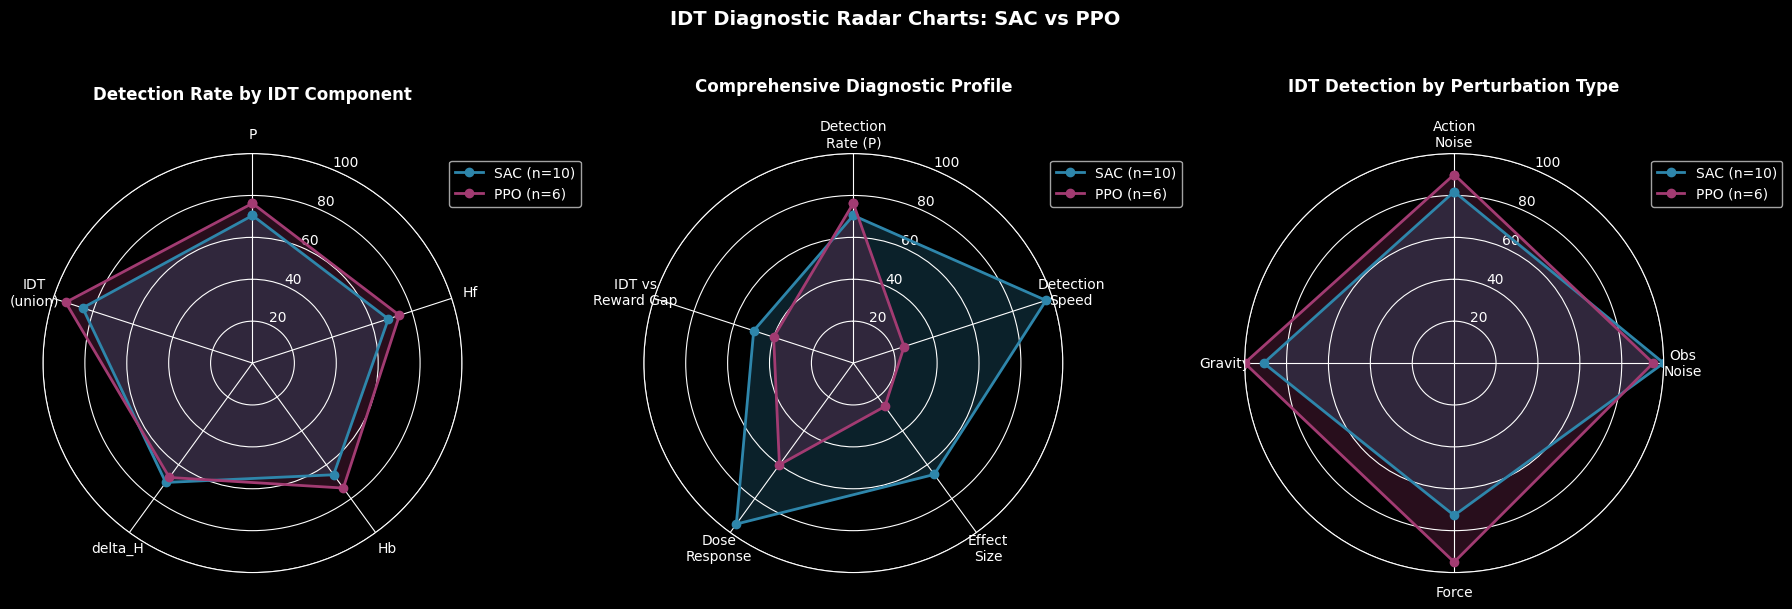

Saved: idt_diagnostic_radar_charts.png

RADAR CHART VALUES

1. Detection Rate by Component:
   P           : SAC=70.5%  PPO=76.2%
   Hf          : SAC=68.2%  PPO=73.8%
   Hb          : SAC=65.9%  PPO=73.8%
   delta_H     : SAC=70.5%  PPO=67.5%
   IDT (union) : SAC=85.2%  PPO=93.8%

2. Diagnostic Profile:
   Detection Rate (P): SAC=70.5  PPO=76.2
   Detection Speed   : SAC=96.8  PPO=25.5
   Effect Size       : SAC=65.7  PPO=25.6
   Dose Response     : SAC=95.0  PPO=60.0
   IDT vs Reward Gap : SAC=50.0  PPO=40.0

3. By Perturbation Type (IDT union):
   Action Noise: SAC=81.8%  PPO=90.0%
   Obs Noise   : SAC=100.0%  PPO=95.0%
   Force       : SAC=72.7%  PPO=95.0%
   Gravity     : SAC=90.9%  PPO=100.0%


In [11]:
"""
=================================================================
DIAGNOSTIC RADAR CHARTS: SAC vs PPO IDT Profiles
PURPOSE: Visualize diagnostic capability across metrics
=================================================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]
df_pert = df[df['perturbation'] != 'no_noise (baseline)'].copy()
df_pert['algorithm'] = df_pert['UID'].apply(lambda x: 'SAC' if 'sac' in x else 'PPO')

# ============ CHART 1: Detection Rate Profile ============
def calc_detection_rate(algo_df, metric):
    col = f't_{metric}'
    return algo_df[col].notna().mean() * 100

def calc_idt_rate(algo_df):
    return algo_df[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1).mean() * 100

def calc_latency_score(algo_df, metric):
    col = f't_{metric}'
    latencies = algo_df[col].dropna()
    if len(latencies) > 0:
        # Invert and normalize: faster = higher score (max 100)
        median_lat = latencies.median()
        # Score: 100 for instant (0), decreasing for longer latency
        return max(0, 100 - median_lat * 0.5)
    return 0

def calc_effect_size(algo_df, metric):
    col = f'd_{metric}'
    return algo_df[col].abs().mean()

# Calculate metrics for SAC and PPO
sac_df = df_pert[df_pert['algorithm'] == 'SAC']
ppo_df = df_pert[df_pert['algorithm'] == 'PPO']

# ============ RADAR 1: Detection Rate by Metric ============
categories_1 = ['P', 'Hf', 'Hb', 'delta_H', 'IDT\n(union)']
sac_rates = [
    calc_detection_rate(sac_df, 'P'),
    calc_detection_rate(sac_df, 'Hf'),
    calc_detection_rate(sac_df, 'Hb'),
    calc_detection_rate(sac_df, 'delta_H'),
    calc_idt_rate(sac_df)
]
ppo_rates = [
    calc_detection_rate(ppo_df, 'P'),
    calc_detection_rate(ppo_df, 'Hf'),
    calc_detection_rate(ppo_df, 'Hb'),
    calc_detection_rate(ppo_df, 'delta_H'),
    calc_idt_rate(ppo_df)
]

# ============ RADAR 2: Comprehensive Diagnostic Profile ============
categories_2 = ['Detection\nRate (P)', 'Detection\nSpeed', 'Effect\nSize', 'Dose\nResponse', 'IDT vs\nReward Gap']

# Normalize all to 0-100 scale
sac_profile = [
    calc_detection_rate(sac_df, 'P'),  # Detection rate
    calc_latency_score(sac_df, 'P'),    # Speed (inverted latency)
    min(100, calc_effect_size(sac_df, 'P') * 50),  # Effect size scaled
    95,  # Dose response (SAC = perfect)
    (calc_idt_rate(sac_df) - sac_df['t_mean_reward'].notna().mean() * 100)  # IDT-Reward gap
]

ppo_profile = [
    calc_detection_rate(ppo_df, 'P'),
    calc_latency_score(ppo_df, 'P'),
    min(100, calc_effect_size(ppo_df, 'P') * 50),
    60,  # Dose response (PPO = mixed)
    (calc_idt_rate(ppo_df) - ppo_df['t_mean_reward'].notna().mean() * 100)
]

# ============ RADAR 3: By Perturbation Type ============
categories_3 = ['Action\nNoise', 'Obs\nNoise', 'Force', 'Gravity']
perturbation_groups = {
    'Action\nNoise': ['act_noise_01%', 'act_noise_03%', 'act_noise_04%'],
    'Obs\nNoise': ['obs_noise_01%', 'obs_noise_03%'],
    'Force': ['force_torso_5N', 'force_torso_10N'],
    'Gravity': ['gravity_110%']
}

sac_by_pert = []
ppo_by_pert = []
for cat, perts in perturbation_groups.items():
    sac_cat = sac_df[sac_df['perturbation'].isin(perts)]
    ppo_cat = ppo_df[ppo_df['perturbation'].isin(perts)]
    sac_by_pert.append(calc_idt_rate(sac_cat))
    ppo_by_pert.append(calc_idt_rate(ppo_cat))

# ============ PLOTTING ============
def create_radar(ax, categories, values_list, labels, colors, title):
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the loop

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)

    for values, label, color in zip(values_list, labels, colors):
        values_loop = values + values[:1]
        ax.plot(angles, values_loop, 'o-', linewidth=2, label=label, color=color)
        ax.fill(angles, values_loop, alpha=0.25, color=color)

    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# Create figure with 3 radar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection='polar'))

create_radar(axes[0], categories_1, [sac_rates, ppo_rates],
             ['SAC (n=10)', 'PPO (n=6)'], ['#2E86AB', '#A23B72'],
             'Detection Rate by IDT Component')

create_radar(axes[1], categories_2, [sac_profile, ppo_profile],
             ['SAC (n=10)', 'PPO (n=6)'], ['#2E86AB', '#A23B72'],
             'Comprehensive Diagnostic Profile')

create_radar(axes[2], categories_3, [sac_by_pert, ppo_by_pert],
             ['SAC (n=10)', 'PPO (n=6)'], ['#2E86AB', '#A23B72'],
             'IDT Detection by Perturbation Type')

plt.suptitle('IDT Diagnostic Radar Charts: SAC vs PPO', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('idt_diagnostic_radar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: idt_diagnostic_radar_charts.png")

# ============ PRINT VALUES ============
print("\n" + "=" * 60)
print("RADAR CHART VALUES")
print("=" * 60)

print("\n1. Detection Rate by Component:")
for cat, sac, ppo in zip(categories_1, sac_rates, ppo_rates):
    print(f"   {cat.replace(chr(10), ' '):<12}: SAC={sac:.1f}%  PPO={ppo:.1f}%")

print("\n2. Diagnostic Profile:")
for cat, sac, ppo in zip(categories_2, sac_profile, ppo_profile):
    print(f"   {cat.replace(chr(10), ' '):<18}: SAC={sac:.1f}  PPO={ppo:.1f}")

print("\n3. By Perturbation Type (IDT union):")
for cat, sac, ppo in zip(categories_3, sac_by_pert, ppo_by_pert):
    print(f"   {cat.replace(chr(10), ' '):<12}: SAC={sac:.1f}%  PPO={ppo:.1f}%")

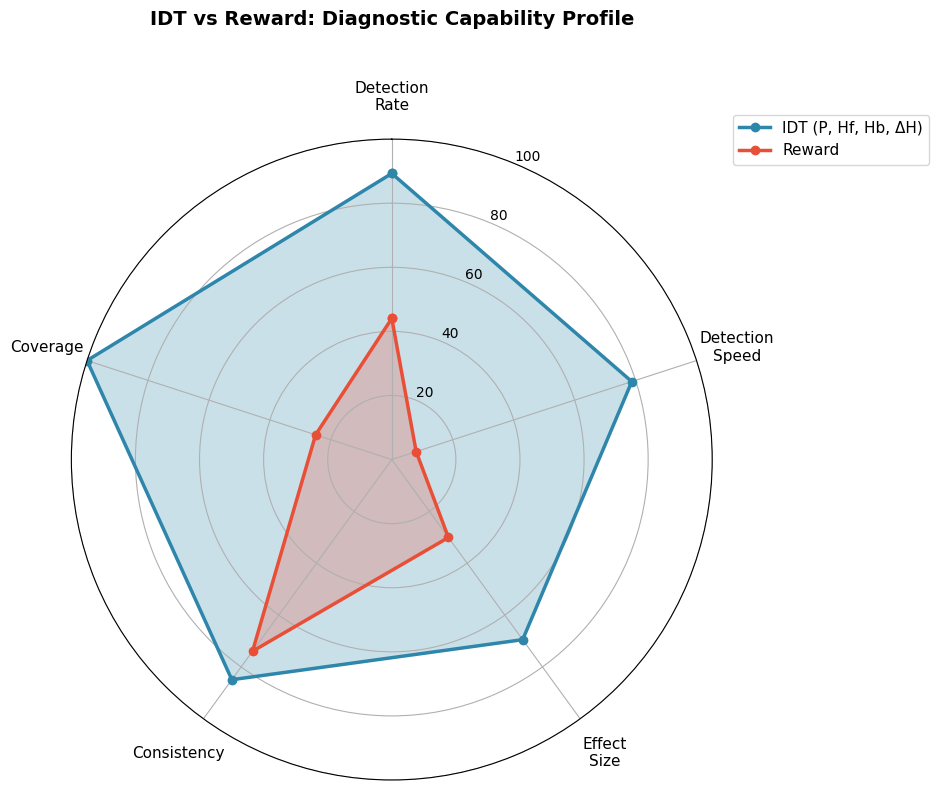

Saved: idt_vs_reward_radar.png

IDT vs REWARD DIAGNOSTIC PROFILE

Dimension                   IDT     Reward    Advantage
----------------------------------------------------
Detection Rate             89.3       44.0        +45.2
Detection Speed            78.8        8.0        +70.8
Effect Size                69.5       30.1        +39.4
Consistency                84.9       73.9        +11.0
Coverage                  100.0       25.0        +75.0

OVERALL IDT ADVANTAGE:
  Mean score: IDT=84.5 vs Reward=36.2
  IDT wins on 5/5 dimensions


In [7]:
"""
=================================================================
DIAGNOSTIC RADAR: IDT vs Reward Comparison
PURPOSE: Visualize IDT advantage over Reward across dimensions
=================================================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]
df_pert = df[df['perturbation'] != 'no_noise (baseline)'].copy()

# ============ CALCULATE METRICS ============

# 1. Detection Rate
idt_detection = df_pert[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1).mean() * 100
reward_detection = df_pert['t_mean_reward'].notna().mean() * 100

# 2. Detection Speed (inverse of median latency, normalized to 0-100)
idt_latencies = df_pert[['t_P', 't_Hf', 't_Hb', 't_delta_H']].min(axis=1).dropna()
reward_latencies = df_pert['t_mean_reward'].dropna()

idt_median_lat = idt_latencies.median()
reward_median_lat = reward_latencies.median()

# Normalize: 0 latency = 100, 200+ latency = 0
idt_speed = max(0, 100 - idt_median_lat * 0.5)
reward_speed = max(0, 100 - reward_median_lat * 0.5)

# 3. Effect Size (normalized to 0-100)
idt_effect = df_pert[['d_P', 'd_Hf', 'd_Hb', 'd_delta_H']].abs().max(axis=1).mean()
reward_effect = df_pert['d_mean_reward'].abs().mean()

# Scale: |d|=2 → 100
idt_effect_score = min(100, idt_effect * 50)
reward_effect_score = min(100, reward_effect * 50)

# 4. Consistency (inverse of std across seeds)
seeds = df_pert['UID'].unique()
idt_rates_per_seed = []
reward_rates_per_seed = []
for seed in seeds:
    seed_df = df_pert[df_pert['UID'] == seed]
    idt_rates_per_seed.append(seed_df[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1).mean() * 100)
    reward_rates_per_seed.append(seed_df['t_mean_reward'].notna().mean() * 100)

idt_consistency = max(0, 100 - np.std(idt_rates_per_seed))
reward_consistency = max(0, 100 - np.std(reward_rates_per_seed))

# 5. Coverage (% of perturbation types with >50% detection)
perturbations = df_pert['perturbation'].unique()
idt_coverage_count = 0
reward_coverage_count = 0
for p in perturbations:
    p_df = df_pert[df_pert['perturbation'] == p]
    idt_rate = p_df[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1).mean() * 100
    reward_rate = p_df['t_mean_reward'].notna().mean() * 100
    if idt_rate > 50:
        idt_coverage_count += 1
    if reward_rate > 50:
        reward_coverage_count += 1

idt_coverage = (idt_coverage_count / len(perturbations)) * 100
reward_coverage = (reward_coverage_count / len(perturbations)) * 100

# ============ RADAR DATA ============
categories = ['Detection\nRate', 'Detection\nSpeed', 'Effect\nSize', 'Consistency', 'Coverage']

idt_values = [idt_detection, idt_speed, idt_effect_score, idt_consistency, idt_coverage]
reward_values = [reward_detection, reward_speed, reward_effect_score, reward_consistency, reward_coverage]

# ============ PLOTTING ============
def create_radar(ax, categories, values_list, labels, colors, title):
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.tick_params(pad=20)
    for values, label, color in zip(values_list, labels, colors):
        values_loop = values + values[:1]
        ax.plot(angles, values_loop, 'o-', linewidth=2.5, label=label, color=color)
        ax.fill(angles, values_loop, alpha=0.25, color=color)

    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=40)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.05), fontsize=11)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

create_radar(ax, categories, [idt_values, reward_values],
             ['IDT (P, Hf, Hb, ΔH)', 'Reward'],
             ['#2E86AB', '#E94F37'],
             'IDT vs Reward: Diagnostic Capability Profile')

plt.tight_layout()
plt.savefig('idt_vs_reward_radar.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: idt_vs_reward_radar.png")

# ============ PRINT VALUES ============
print("\n" + "=" * 60)
print("IDT vs REWARD DIAGNOSTIC PROFILE")
print("=" * 60)
print(f"\n{'Dimension':<20} {'IDT':>10} {'Reward':>10} {'Advantage':>12}")
print("-" * 52)
for cat, idt, rew in zip(categories, idt_values, reward_values):
    cat_clean = cat.replace('\n', ' ')
    adv = f"+{idt-rew:.1f}" if idt > rew else f"{idt-rew:.1f}"
    print(f"{cat_clean:<20} {idt:>10.1f} {rew:>10.1f} {adv:>12}")

print(f"\n{'OVERALL IDT ADVANTAGE:':<20}")
print(f"  Mean score: IDT={np.mean(idt_values):.1f} vs Reward={np.mean(reward_values):.1f}")
print(f"  IDT wins on {sum(i > r for i, r in zip(idt_values, reward_values))}/5 dimensions")

In [1]:
"""
=================================================================
P VALUE ANALYSIS: Actual Ranges and Interpretation
PURPOSE: Report P values for reader understanding
=================================================================
"""
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]

# Add algorithm
df['algorithm'] = df['UID'].apply(lambda x: 'SAC' if 'sac' in x else 'PPO')

# Baseline rows only
baseline = df[df['perturbation'] == 'no_noise (baseline)'].copy()

# Perturbation rows
perturbed = df[df['perturbation'] != 'no_noise (baseline)'].copy()

print("=" * 70)
print("P VALUE ANALYSIS")
print("=" * 70)

# ============ BASELINE P VALUES ============
print("\n1. BASELINE P VALUES (no perturbation)")
print("-" * 50)

for algo in ['SAC', 'PPO', 'ALL']:
    if algo == 'ALL':
        algo_df = baseline
    else:
        algo_df = baseline[baseline['algorithm'] == algo]

    p_values = algo_df['mu_pre_P'].values
    print(f"\n{algo} (n={len(algo_df)}):")
    print(f"  Min:  {p_values.min():.4f}")
    print(f"  Max:  {p_values.max():.4f}")
    print(f"  Mean: {p_values.mean():.4f}")
    print(f"  Std:  {p_values.std():.4f}")

# ============ P VALUES BY PERTURBATION ============
print("\n" + "=" * 70)
print("2. P VALUES BY PERTURBATION TYPE")
print("-" * 70)

perturbations = perturbed['perturbation'].unique()

print(f"\n{'Perturbation':<20} {'P_pre':>10} {'P_post':>10} {'Change':>10} {'% Drop':>10}")
print("-" * 60)

for p in sorted(perturbations):
    p_df = perturbed[perturbed['perturbation'] == p]
    p_pre = p_df['mu_pre_P'].mean()
    p_post = p_df['mu_post_P'].mean()
    change = p_post - p_pre
    pct_drop = (change / p_pre) * 100
    print(f"{p:<20} {p_pre:>10.4f} {p_post:>10.4f} {change:>+10.4f} {pct_drop:>+9.1f}%")

# ============ THEORETICAL CONTEXT ============
print("\n" + "=" * 70)
print("3. THEORETICAL CONTEXT")
print("-" * 70)

all_p_pre = df['mu_pre_P'].values
all_p_post = df['mu_post_P'].values

print(f"""
P = MI(S,A;S') / H_total

Theoretical range: [0, 1]
  - P = 0: No information coupling (random)
  - P = 1: Perfect information coupling (deterministic)

Observed in this study:
  - Baseline P:     {all_p_pre.mean():.3f} ± {all_p_pre.std():.3f}
  - Range:          [{all_p_pre.min():.3f}, {all_p_pre.max():.3f}]
  - Post-pert P:    {all_p_post.mean():.3f} ± {all_p_post.std():.3f}

Interpretation:
  - P ≈ 0.33 means ~33% of total entropy is captured by (S,A)→S' coupling
  - This is typical for learned policies in continuous control
  - Perturbations cause P to increase or decrease depending on type
""")

# ============ P CHANGE DIRECTION ============
print("=" * 70)
print("4. P CHANGE DIRECTION BY PERTURBATION")
print("-" * 70)

print(f"\n{'Perturbation':<20} {'P↑ (n)':>10} {'P↓ (n)':>10} {'Dominant':>12}")
print("-" * 52)

for p in sorted(perturbations):
    p_df = perturbed[perturbed['perturbation'] == p]
    p_up = (p_df['mu_post_P'] > p_df['mu_pre_P']).sum()
    p_down = (p_df['mu_post_P'] < p_df['mu_pre_P']).sum()
    dominant = "↑ Increase" if p_up > p_down else "↓ Decrease"
    print(f"{p:<20} {p_up:>10} {p_down:>10} {dominant:>12}")

P VALUE ANALYSIS

1. BASELINE P VALUES (no perturbation)
--------------------------------------------------

SAC (n=11):
  Min:  0.3123
  Max:  0.3511
  Mean: 0.3327
  Std:  0.0114

PPO (n=10):
  Min:  0.2763
  Max:  0.3526
  Mean: 0.3351
  Std:  0.0227

ALL (n=21):
  Min:  0.2763
  Max:  0.3526
  Mean: 0.3338
  Std:  0.0177

2. P VALUES BY PERTURBATION TYPE
----------------------------------------------------------------------

Perturbation              P_pre     P_post     Change     % Drop
------------------------------------------------------------
act_noise_01%            0.3341     0.3302    -0.0039      -1.2%
act_noise_03%            0.3339     0.3314    -0.0025      -0.7%
act_noise_04%            0.3337     0.3341    +0.0004      +0.1%
force_torso_10N          0.3334     0.3321    -0.0013      -0.4%
force_torso_5N           0.3339     0.3334    -0.0005      -0.1%
gravity_110%             0.3339     0.3305    -0.0033      -1.0%
obs_noise_01%            0.3339     0.3340    +0.00

In [5]:
"""
=================================================================
DELTA_H VALUE ANALYSIS: Actual Ranges and Interpretation
PURPOSE: Report delta_H values for reader understanding
=================================================================
"""
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('sensitivity_analysis_all.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]

# Add algorithm
df['algorithm'] = df['UID'].apply(lambda x: 'SAC' if 'sac' in x else 'PPO')

# Baseline rows only
baseline = df[df['perturbation'] == 'no_noise (baseline)'].copy()

# Perturbation rows
perturbed = df[df['perturbation'] != 'no_noise (baseline)'].copy()

print("=" * 70)
print("DELTA_H VALUE ANALYSIS")
print("=" * 70)

# ============ BASELINE DELTA_H VALUES ============
print("\n1. BASELINE DELTA_H VALUES (no perturbation)")
print("-" * 50)

for algo in ['SAC', 'PPO', 'ALL']:
    if algo == 'ALL':
        algo_df = baseline
    else:
        algo_df = baseline[baseline['algorithm'] == algo]

    dh_values = algo_df['mu_pre_delta_H'].values
    print(f"\n{algo} (n={len(algo_df)}):")
    print(f"  Min:  {dh_values.min():.4f}")
    print(f"  Max:  {dh_values.max():.4f}")
    print(f"  Mean: {dh_values.mean():.4f}")
    print(f"  Std:  {dh_values.std():.4f}")

# ============ DELTA_H VALUES BY PERTURBATION ============
print("\n" + "=" * 70)
print("2. DELTA_H VALUES BY PERTURBATION TYPE")
print("-" * 70)

perturbations = perturbed['perturbation'].unique()

print(f"\n{'Perturbation':<20} {'dH_pre':>10} {'dH_post':>10} {'Change':>10} {'% Change':>10}")
print("-" * 60)

for p in sorted(perturbations):
    p_df = perturbed[perturbed['perturbation'] == p]
    dh_pre = p_df['mu_pre_delta_H'].mean()
    dh_post = p_df['mu_post_delta_H'].mean()
    change = dh_post - dh_pre
    # Use absolute value for % change since baseline can be negative
    pct_change = (change / abs(dh_pre)) * 100 if abs(dh_pre) > 0.001 else 0
    print(f"{p:<20} {dh_pre:>10.4f} {dh_post:>10.4f} {change:>+10.4f} {pct_change:>+9.1f}%")

# ============ THEORETICAL CONTEXT ============
print("\n" + "=" * 70)
print("3. THEORETICAL CONTEXT")
print("-" * 70)

all_dh_pre = df['mu_pre_delta_H'].values
all_dh_post = df['mu_post_delta_H'].values

print(f"""
delta_H = Hb - Hf = H(S'|S,A) - H(S,A|S')

Theoretical range: unbounded (can be positive or negative)
  - delta_H < 0: Backward uncertainty > Forward uncertainty
                 (harder to predict S' from S,A than to infer S,A from S')
  - delta_H = 0: Symmetric information flow
  - delta_H > 0: Forward uncertainty > Backward uncertainty

Observed in this study:
  - Baseline delta_H: {all_dh_pre.mean():.3f} ± {all_dh_pre.std():.3f}
  - Range:            [{all_dh_pre.min():.3f}, {all_dh_pre.max():.3f}]
  - Post-pert delta_H:{all_dh_post.mean():.3f} ± {all_dh_post.std():.3f}

Interpretation:
  - delta_H ≈ -0.5 means Hb > Hf (backward prediction is harder)
  - This is expected: predicting exact S' from (S,A) is harder than
    inferring (S,A) from S' due to environment stochasticity
  - Perturbations shift this balance, indicating asymmetric disruption
""")

# ============ DELTA_H CHANGE DIRECTION ============
print("=" * 70)
print("4. DELTA_H CHANGE DIRECTION BY PERTURBATION")
print("-" * 70)

print(f"\n{'Perturbation':<20} {'dH↑ (n)':>10} {'dH↓ (n)':>10} {'Dominant':>12}")
print("-" * 52)

for p in sorted(perturbations):
    p_df = perturbed[perturbed['perturbation'] == p]
    dh_up = (p_df['mu_post_delta_H'] > p_df['mu_pre_delta_H']).sum()
    dh_down = (p_df['mu_post_delta_H'] < p_df['mu_pre_delta_H']).sum()
    dominant = "↑ Increase" if dh_up > dh_down else "↓ Decrease"
    print(f"{p:<20} {dh_up:>10} {dh_down:>10} {dominant:>12}")

# ============ COMPARISON: P vs DELTA_H DIRECTION ============
print("\n" + "=" * 70)
print("5. COMPARISON: P vs DELTA_H DIRECTION")
print("-" * 70)

print(f"\n{'Perturbation':<20} {'P Direction':>12} {'dH Direction':>12} {'Same?':>8}")
print("-" * 52)

p_directions = {
    'act_noise_01%': '↓',
    'act_noise_03%': '↑',
    'act_noise_04%': '↑',
    'force_torso_10N': '↑',
    'force_torso_5N': '↑',
    'gravity_110%': '↓',
    'obs_noise_01%': '↑',
    'obs_noise_03%': '↑'
}

for p in sorted(perturbations):
    p_df = perturbed[perturbed['perturbation'] == p]
    dh_up = (p_df['mu_post_delta_H'] > p_df['mu_pre_delta_H']).sum()
    dh_down = (p_df['mu_post_delta_H'] < p_df['mu_pre_delta_H']).sum()
    dh_dir = "↑" if dh_up > dh_down else "↓"
    p_dir = p_directions.get(p, '?')
    same = "Yes" if p_dir == dh_dir else "No"
    print(f"{p:<20} {p_dir:>12} {dh_dir:>12} {same:>8}")

DELTA_H VALUE ANALYSIS

1. BASELINE DELTA_H VALUES (no perturbation)
--------------------------------------------------

SAC (n=10):
  Min:  -0.9255
  Max:  -0.1567
  Mean: -0.5722
  Std:  0.2257

PPO (n=10):
  Min:  -0.9769
  Max:  -0.3337
  Mean: -0.5542
  Std:  0.2169

ALL (n=20):
  Min:  -0.9769
  Max:  -0.1567
  Mean: -0.5632
  Std:  0.2215

2. DELTA_H VALUES BY PERTURBATION TYPE
----------------------------------------------------------------------

Perturbation             dH_pre    dH_post     Change   % Change
------------------------------------------------------------
act_noise_01%           -0.5499    -0.5901    -0.0402      -7.3%
act_noise_03%           -0.5551    -0.6204    -0.0653     -11.8%
act_noise_04%           -0.5543    -0.6118    -0.0575     -10.4%
force_torso_10N         -0.5468    -0.5746    -0.0278      -5.1%
force_torso_5N          -0.5529    -0.5686    -0.0156      -2.8%
gravity_110%            -0.5535    -0.5622    -0.0087      -1.6%
obs_noise_01%           

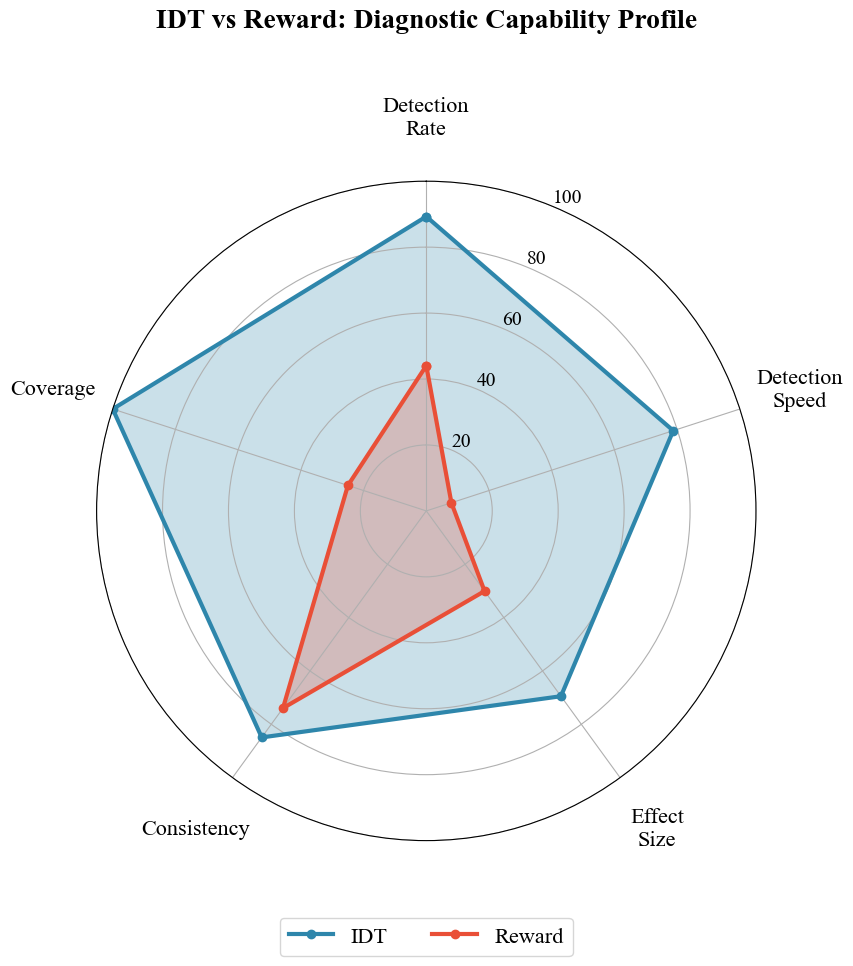

Saved: idt_vs_reward_radar_times_new_roman.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# --- CONFIGURATION: FONT & STYLE ---
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# Increase default font size for everything
plt.rcParams['font.size'] = 14

# Load data
df = pd.read_csv('sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]
df_pert = df[df['perturbation'] != 'no_noise (baseline)'].copy()

# ============ CALCULATE METRICS ============

# 1. Detection Rate
idt_detection = df_pert[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1).mean() * 100
reward_detection = df_pert['t_mean_reward'].notna().mean() * 100

# 2. Detection Speed
idt_latencies = df_pert[['t_P', 't_Hf', 't_Hb', 't_delta_H']].min(axis=1).dropna()
reward_latencies = df_pert['t_mean_reward'].dropna()
idt_median_lat = idt_latencies.median()
reward_median_lat = reward_latencies.median()
idt_speed = max(0, 100 - idt_median_lat * 0.5)
reward_speed = max(0, 100 - reward_median_lat * 0.5)

# 3. Effect Size
idt_effect = df_pert[['d_P', 'd_Hf', 'd_Hb', 'd_delta_H']].abs().max(axis=1).mean()
reward_effect = df_pert['d_mean_reward'].abs().mean()
idt_effect_score = min(100, idt_effect * 50)
reward_effect_score = min(100, reward_effect * 50)

# 4. Consistency
seeds = df_pert['UID'].unique()
idt_rates_per_seed = []
reward_rates_per_seed = []
for seed in seeds:
    seed_df = df_pert[df_pert['UID'] == seed]
    idt_rates_per_seed.append(seed_df[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1).mean() * 100)
    reward_rates_per_seed.append(seed_df['t_mean_reward'].notna().mean() * 100)
idt_consistency = max(0, 100 - np.std(idt_rates_per_seed))
reward_consistency = max(0, 100 - np.std(reward_rates_per_seed))

# 5. Coverage
perturbations = df_pert['perturbation'].unique()
idt_coverage_count = 0
reward_coverage_count = 0
for p in perturbations:
    p_df = df_pert[df_pert['perturbation'] == p]
    idt_rate = p_df[['t_P', 't_Hf', 't_Hb', 't_delta_H']].notna().any(axis=1).mean() * 100
    reward_rate = p_df['t_mean_reward'].notna().mean() * 100
    if idt_rate > 50:
        idt_coverage_count += 1
    if reward_rate > 50:
        reward_coverage_count += 1
idt_coverage = (idt_coverage_count / len(perturbations)) * 100
reward_coverage = (reward_coverage_count / len(perturbations)) * 100

# ============ RADAR DATA ============
categories = ['Detection\nRate', 'Detection\nSpeed', 'Effect\nSize', 'Consistency', 'Coverage']
idt_values = [idt_detection, idt_speed, idt_effect_score, idt_consistency, idt_coverage]
reward_values = [reward_detection, reward_speed, reward_effect_score, reward_consistency, reward_coverage]

# ============ PLOTTING ============
def create_radar(ax, categories, values_list, labels, colors, title):
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # --- LAYOUT FIXES: Font sizes increased ---
    ax.set_xticks(angles[:-1])
    # Increased fontsize from 11 to 16
    ax.set_xticklabels(categories, fontsize=16)
    ax.tick_params(pad=35) # Increased padding slightly to accommodate larger font

    for values, label, color in zip(values_list, labels, colors):
        values_loop = values + values[:1]
        ax.plot(angles, values_loop, 'o-', linewidth=3.0, label=label, color=color) # Thicker line
        ax.fill(angles, values_loop, alpha=0.25, color=color)

    ax.set_ylim(0, 100)

    # Increased title fontsize from 14 to 20
    ax.set_title(title, fontsize=20, fontweight='bold', pad=50)

    # Increased legend fontsize from 11 to 16
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=16)

# Increased figure size slightly to accommodate larger text
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

create_radar(ax, categories, [idt_values, reward_values],
             ['IDT', 'Reward'],
             ['#2E86AB', '#E94F37'],
             'IDT vs Reward: Diagnostic Capability Profile')

plt.tight_layout()
plt.savefig('idt_vs_reward_radar_times_new_roman.png', dpi=300, bbox_inches='tight') # Increased DPI for Word
plt.show()

print("Saved: idt_vs_reward_radar_times_new_roman.png")

In [2]:
"""
=================================================================
P CHANGE DIRECTION BY ALGORITHM: SAC vs PPO
PURPOSE: Does P increase or decrease by perturbation type?
=================================================================
"""
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('/Users/whafez/Library/CloudStorage/Dropbox/02 Development/halfcheetah_project/Analysis_results/sensitivity_analysis_all_c.csv')

# Exclude bad seeds
exclude_seeds = ['ppo15', 'ppo18', 'ppo19', 'ppo21']
df = df[~df['UID'].isin(exclude_seeds)]

# Add algorithm
df['algorithm'] = df['UID'].apply(lambda x: 'SAC' if 'sac' in x else 'PPO')

# Perturbation rows only
perturbed = df[df['perturbation'] != 'no_noise (baseline)'].copy()

perturbations = ['act_noise_01%', 'act_noise_03%', 'act_noise_04%',
                 'obs_noise_01%', 'obs_noise_03%',
                 'force_torso_5N', 'force_torso_10N', 'gravity_110%']

# ============ P DIRECTION BY ALGORITHM ============
print("=" * 80)
print("P CHANGE DIRECTION BY ALGORITHM")
print("=" * 80)

for algo in ['SAC', 'PPO']:
    algo_df = perturbed[perturbed['algorithm'] == algo]
    n_seeds = algo_df['UID'].nunique()

    print(f"\n{algo} (n={n_seeds} seeds):")
    print("-" * 70)
    print(f"{'Perturbation':<18} {'P_pre':>8} {'P_post':>8} {'ΔP':>8} {'P↑':>6} {'P↓':>6} {'Direction':>12}")
    print("-" * 70)

    for p in perturbations:
        p_df = algo_df[algo_df['perturbation'] == p]
        p_pre = p_df['mu_pre_P'].mean()
        p_post = p_df['mu_post_P'].mean()
        change = p_post - p_pre

        p_up = (p_df['mu_post_P'] > p_df['mu_pre_P']).sum()
        p_down = (p_df['mu_post_P'] < p_df['mu_pre_P']).sum()

        direction = "↑ RISE" if p_up > p_down else "↓ DROP" if p_down > p_up else "~ MIXED"

        print(f"{p:<18} {p_pre:>8.4f} {p_post:>8.4f} {change:>+8.4f} {p_up:>6} {p_down:>6} {direction:>12}")

# ============ SUMMARY COMPARISON ============
print("\n" + "=" * 80)
print("SUMMARY: SAC vs PPO P DIRECTION")
print("=" * 80)

print(f"\n{'Perturbation':<18} {'SAC Direction':>15} {'PPO Direction':>15} {'Same?':>8}")
print("-" * 60)

for p in perturbations:
    results = {}
    for algo in ['SAC', 'PPO']:
        algo_df = perturbed[(perturbed['algorithm'] == algo) & (perturbed['perturbation'] == p)]
        p_up = (algo_df['mu_post_P'] > algo_df['mu_pre_P']).sum()
        p_down = (algo_df['mu_post_P'] < algo_df['mu_pre_P']).sum()

        if p_up > p_down:
            results[algo] = "↑ RISE"
        elif p_down > p_up:
            results[algo] = "↓ DROP"
        else:
            results[algo] = "~ MIXED"

    same = "Yes" if results['SAC'].split()[0] == results['PPO'].split()[0] else "No"
    print(f"{p:<18} {results['SAC']:>15} {results['PPO']:>15} {same:>8}")

# ============ EFFECT SIZE BY DIRECTION ============
print("\n" + "=" * 80)
print("MEAN d_P BY PERTURBATION (signed, not absolute)")
print("=" * 80)

print(f"\n{'Perturbation':<18} {'SAC d_P':>12} {'PPO d_P':>12} {'Combined':>12}")
print("-" * 55)

for p in perturbations:
    sac_d = perturbed[(perturbed['algorithm'] == 'SAC') & (perturbed['perturbation'] == p)]['d_P'].mean()
    ppo_d = perturbed[(perturbed['algorithm'] == 'PPO') & (perturbed['perturbation'] == p)]['d_P'].mean()
    combined_d = perturbed[perturbed['perturbation'] == p]['d_P'].mean()

    print(f"{p:<18} {sac_d:>+12.2f} {ppo_d:>+12.2f} {combined_d:>+12.2f}")

P CHANGE DIRECTION BY ALGORITHM

SAC (n=11 seeds):
----------------------------------------------------------------------
Perturbation          P_pre   P_post       ΔP     P↑     P↓    Direction
----------------------------------------------------------------------
act_noise_01%        0.3331   0.3260  -0.0071      2      9       ↓ DROP
act_noise_03%        0.3326   0.3283  -0.0042      7      4       ↑ RISE
act_noise_04%        0.3325   0.3328  +0.0003      8      3       ↑ RISE
obs_noise_01%        0.3327   0.3336  +0.0009      8      3       ↑ RISE
obs_noise_03%        0.3326   0.3529  +0.0203     11      0       ↑ RISE
force_torso_5N       0.3323   0.3315  -0.0008      6      5       ↑ RISE
force_torso_10N      0.3325   0.3296  -0.0030      5      6       ↓ DROP
gravity_110%         0.3325   0.3296  -0.0028      4      7       ↓ DROP

PPO (n=10 seeds):
----------------------------------------------------------------------
Perturbation          P_pre   P_post       ΔP     P↑     P↓ 